# MLP a partir de uma estrutura de grafo — Heart Disease Dataset

Este notebook implementa uma **rede neural Multi-Layer Perceptron (MLP) do zero**
(sem `torch`/`tensorflow`/`keras`), representando a arquitetura como um **grafo
direcionado** (`networkx.DiGraph`): cada **neurônio é um nó** e cada **conexão
sináptica é uma aresta com um peso**. A partir dessa estrutura implementamos:

1. **Feedforward** — propagação das ativações pelo grafo, camada a camada.
2. **Backpropagation** — cálculo dos gradientes e atualização dos pesos (arestas)
   e vieses (nós) do grafo.
3. **Treinamento** na base **Heart Disease** (Kaggle, `johnsmith88/heart-disease-dataset`),
   com split **80% treino / 20% teste**.
4. **Inferência** sobre o conjunto de teste.
5. **Visualização em tempo real** do grafo (pesos das arestas e ativações dos nós)
   e das curvas de treinamento, atualizadas a cada época dentro do próprio notebook.
6. **Escolha de hiperparâmetros com evidência empírica** (validação cruzada,
   regularização L2, e um teste real do efeito da padronização das features).
7. Um **cartão de parâmetros** ao final, pronto para colar num slide.

> **Motor compartilhado**: toda a implementação (grafo, feedforward,
> backpropagation, treino) mora em [`mlp_graph.py`](../mlp_graph.py), importado
> aqui e também pelo app **[Streamlit](../app_streamlit.py)**
> (`streamlit run app_streamlit.py`) — os dois usam exatamente o mesmo código,
> então o que você vê treinar aqui é o mesmo motor que dá para inspecionar
> interativamente (sliders de arquitetura/learning rate/L2/épocas) no
> Streamlit. O código-fonte das funções principais é exibido abaixo com
> `inspect.getsource`, para deixar a implementação visível mesmo sendo
> importada de um módulo.

> **Sobre o dataset**: o download é feito automaticamente via `kagglehub`
> (`kagglehub.dataset_download("johnsmith88/heart-disease-dataset")`), que baixa
> datasets públicos do Kaggle sem exigir login/token. Como fallback, uma cópia
> local (`data/heart.csv`) já está incluída no repositório — se o download
> falhar (ex.: sem internet), o notebook usa essa cópia automaticamente.


In [1]:
# Imports e configuração geral
import os
import sys
import time
import json
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import clear_output

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

# mlp_graph.py mora na raiz do projeto (um nível acima de notebooks/)
sys.path.append(os.path.abspath(".."))
import mlp_graph
from mlp_graph import (
    DEFAULT_CONFIG, GraphMLP,
    relu, relu_deriv, sigmoid, bce_loss, accuracy,
    build_graph, graph_to_params, params_to_graph, sync_activations, copy_params,
    feedforward_graph_single, feedforward, backward, update_params,
    draw_graph_panel, edge_colors_widths,
    COLOR_TRAIN, COLOR_TEST, COLOR_POS_W, COLOR_NEG_W, COLOR_MID_W, INK, MUTED,
)

SEED = DEFAULT_CONFIG["seed"]
np.random.seed(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": MUTED,
    "axes.grid": True,
    "grid.color": "#e7e6e1",
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

print("Setup ok. Configuração padrão (mlp_graph.DEFAULT_CONFIG):")
for k, v in DEFAULT_CONFIG.items():
    print(f"  {k}: {v}")


Setup ok. Configuração padrão (mlp_graph.DEFAULT_CONFIG):
  architecture: [13, 8, 5, 1]
  hidden_activation: relu
  output_activation: sigmoid
  weight_init: he_normal
  loss: binary_cross_entropy
  learning_rate: 0.05
  l2: 0.1
  epochs: 300
  batch_size: 32
  optimizer: mini-batch gradient descent
  preprocessing: standardize (StandardScaler, fit no treino)
  seed: 42


## 1. Aquisição dos dados

Tentamos baixar o dataset via `kagglehub` (funciona sem autenticação para
datasets públicos). Se isso falhar por qualquer motivo, usamos a cópia local
`data/heart.csv` incluída no projeto.


In [2]:
DATA_PATH = os.path.join("..", "data", "heart.csv")

csv_path = None
try:
    import kagglehub
    kaggle_dir = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")
    candidate = os.path.join(kaggle_dir, "heart.csv")
    if os.path.exists(candidate):
        csv_path = candidate
        print(f"Dataset baixado via kagglehub em: {csv_path}")
except Exception as e:
    print(f"kagglehub indisponível ou falhou ({type(e).__name__}: {e}). Usando cópia local.")

if csv_path is None:
    csv_path = DATA_PATH
    print(f"Usando cópia local: {csv_path}")

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
df.head()


Dataset baixado via kagglehub em: /Users/andrezafalcao/.cache/kagglehub/datasets/johnsmith88/heart-disease-dataset/versions/2/heart.csv
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Análise exploratória rápida

13 variáveis clínicas + a coluna `target` (1 = presença de doença cardíaca,
0 = ausência).


In [3]:
df.info()
print()
print("Valores ausentes por coluna:")
print(df.isna().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Valores ausentes por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
d

### Atenção: linhas duplicadas

Esta versão específica do dataset no Kaggle (`johnsmith88/heart-disease-dataset`)
é conhecida por conter **muitas linhas duplicadas** — na prática ela replica o
dataset original (Cleveland/UCI, 303 pacientes) várias vezes. Isso é importante
porque, se não tratado, um split aleatório 80/20 pode colocar **o mesmo paciente
em treino e em teste**, inflando artificialmente a acurácia (vazamento de dados).
Verificamos e removemos as duplicatas antes de dividir os dados.


In [4]:
n_before = len(df)
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Linhas antes: {n_before} | duplicadas removidas: {n_dup} | linhas únicas restantes: {len(df)}")


Linhas antes: 1025 | duplicadas removidas: 723 | linhas únicas restantes: 302


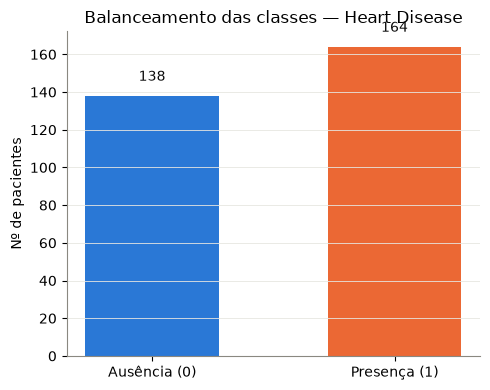

In [5]:
counts = df["target"].value_counts().sort_index()
labels = ["Ausência (0)", "Presença (1)"]
colors = [COLOR_TRAIN, COLOR_TEST]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, counts.values, color=colors, width=0.55)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 8, str(v), ha="center", color=INK, fontsize=10)
ax.set_ylabel("Nº de pacientes")
ax.set_title("Balanceamento das classes — Heart Disease")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()


## 3. Pré-processamento e split 80/20

- Features padronizadas (`StandardScaler`), ajustado **apenas no treino** para
  evitar vazamento de dados.
- Split estratificado 80% treino / 20% teste.


In [6]:
feature_cols = [c for c in df.columns if c != "target"]
X = df[feature_cols].values.astype(np.float64)
y = df["target"].values.astype(np.float64).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Treino:", X_train.shape, " Teste:", X_test.shape)
print(f"Proporção treino/teste: {len(X_train)/len(X):.0%} / {len(X_test)/len(X):.0%}")


Treino: (241, 13)  Teste: (61, 13)
Proporção treino/teste: 80% / 20%


## 4. A MLP como grafo

**Representação:** um `networkx.DiGraph` onde:

- cada **nó** `LxNy` = neurônio `y` da camada `x`, com atributos `bias`, `z`
  (pré-ativação) e `a` (ativação);
- cada **aresta** `(LxNy, L(x+1)Nz)` = conexão sináptica, com atributo `weight`.

O grafo é totalmente conectado entre camadas consecutivas (topologia clássica
de MLP), mas por ser um grafo genérico nada impede estendê-lo depois para
conexões esparsas ou *skip connections*.

**Duas implementações de feedforward, para fins didáticos:**

1. `feedforward_graph_single` — percorre o grafo **nó a nó, aresta a aresta**,
   em ordem topológica, exatamente como a estrutura de grafo sugere. É a versão
   mais literal e serve para validar a implementação vetorizada.
2. `feedforward` (usada no treino) — extrai as matrizes de peso/bias de cada
   camada a partir do grafo e vetoriza os cálculos com `numpy`, o que é
   ordens de magnitude mais rápido para treinar em lote. Após cada atualização
   de gradiente, os pesos são **escritos de volta nas arestas do grafo** — ou
   seja, o grafo é a fonte de verdade dos parâmetros durante todo o treino.

Validamos abaixo que as duas dão o mesmo resultado. O código-fonte de cada
função vem de [`mlp_graph.py`](../mlp_graph.py) — exibido aqui com
`inspect.getsource` para deixar a implementação visível mesmo sendo
importada de um módulo compartilhado com o app Streamlit.


In [7]:
for fn in [build_graph, graph_to_params, params_to_graph, sync_activations,
           feedforward_graph_single, feedforward, backward, update_params]:
    print(inspect.getsource(fn))


def build_graph(layer_sizes, seed=42):
    """Cria o grafo da MLP: nós = neurônios, arestas = pesos."""
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    for l, size in enumerate(layer_sizes):
        for i in range(size):
            G.add_node(
                f"L{l}N{i}", layer=l, a=0.0, z=0.0,
                bias=0.0 if l == 0 else float(rng.normal(0, 0.1)),
            )
    for l in range(len(layer_sizes) - 1):
        fan_in = layer_sizes[l]
        scale = np.sqrt(2.0 / fan_in)  # inicialização He (boa para ReLU)
        for i in range(layer_sizes[l]):
            for j in range(layer_sizes[l + 1]):
                G.add_edge(f"L{l}N{i}", f"L{l+1}N{j}", weight=float(rng.normal(0, scale)))
    return G

def graph_to_params(G, layer_sizes):
    """Extrai (W, b) de cada camada a partir das arestas/nós do grafo."""
    params = []
    for l in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[l], layer_sizes[l + 1]
        W = np.zeros((n_in, n_out))
    

**Sanity check** — a propagação nó-a-nó (`feedforward_graph_single`) deve
produzir exatamente a mesma saída que a versão vetorizada (`feedforward`) para a
mesma amostra e os mesmos pesos, já que ambas implementam a mesma matemática a
partir do mesmo grafo.


In [8]:
_layer_sizes_check = DEFAULT_CONFIG["architecture"]
assert _layer_sizes_check[0] == X_train.shape[1], "arquitetura não bate com o nº de features"
_G_check = build_graph(_layer_sizes_check, seed=SEED)
_params_check = graph_to_params(_G_check, _layer_sizes_check)

out_graph = feedforward_graph_single(_G_check, _layer_sizes_check, X_train[0])
out_vectorized, _ = feedforward(X_train[:1], _params_check)

print("Saída (percurso no grafo):   ", out_graph)
print("Saída (forma vetorizada):    ", out_vectorized[-1][0])
assert np.allclose(out_graph, out_vectorized[-1][0], atol=1e-10), "As duas implementações divergem!"
print("\nOK: as duas implementações de feedforward concordam.")


Saída (percurso no grafo):    [0.1449189]
Saída (forma vetorizada):     [0.1449189]

OK: as duas implementações de feedforward concordam.


## 5. Visualização do grafo em tempo real

Usamos `networkx` para desenhar o grafo e a API `IPython.display.clear_output`
para **redesenhar a figura a cada época** dentro da mesma célula, criando o
efeito de atualização em tempo real diretamente no notebook (sem precisar de
servidor externo). Cada atualização mostra, lado a lado:

- o **grafo** — espessura/cor das arestas = magnitude/sinal do peso (azul =
  peso positivo, vermelho = peso negativo, cinza = próximo de zero); cor dos
  nós = ativação atual de um exemplo de referência;
- a **curva de perda** (BCE) e a **curva de acurácia**, treino vs. teste,
  atualizadas até a época corrente.

> Observação: essa animação é melhor apreciada executando o notebook
> interativamente (Jupyter/VS Code) — ao exportar/renderizar estaticamente
> (ex.: `nbconvert`), só o último quadro fica salvo no arquivo.


In [9]:
print(inspect.getsource(edge_colors_widths))
print(inspect.getsource(draw_graph_panel))


def edge_colors_widths(G):
    from matplotlib.colors import LinearSegmentedColormap
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()])
    max_abs = max(np.max(np.abs(weights)), 1e-9) if len(weights) else 1.0
    norm = weights / max_abs  # em [-1, 1]
    cmap = LinearSegmentedColormap.from_list("diverging_w", [COLOR_NEG_W, COLOR_MID_W, COLOR_POS_W])
    colors = [cmap((n + 1) / 2) for n in norm]
    widths = 0.6 + 3.0 * np.abs(norm)
    return colors, widths

def draw_graph_panel(ax, G, pos, title):
    colors, widths = edge_colors_widths(G)
    node_colors = [G.nodes[n]["a"] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=colors, width=widths, arrows=False)
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_color=node_colors, cmap="Blues", vmin=0, vmax=1,
        node_size=220, edgecolors=INK, linewidths=0.4,
    )
    ax.set_title(title, fontsize=10)
    ax.axis("off")



In [10]:
def live_training_plot(epoch, epochs, history, model):
    """Callback passado como `on_epoch=` para `GraphMLP.train` — chamado a
    cada `visualize_every` épocas. Sincroniza as ativações de uma amostra de
    referência nos nós do grafo e redesenha grafo + curvas de treino."""
    sample_caches, _ = model.forward(X_train[:1])
    sync_activations(model.G, model.layer_sizes, [c[0] for c in sample_caches])

    clear_output(wait=True)
    fig, (ax_graph, ax_loss, ax_acc) = plt.subplots(1, 3, figsize=(16, 4.5))

    draw_graph_panel(ax_graph, model.G, model.pos, f"Grafo — pesos e ativações | época {epoch}/{epochs}")

    ep_range = range(1, len(history["train_loss"]) + 1)
    ax_loss.plot(ep_range, history["train_loss"], color=COLOR_TRAIN, label="Treino")
    ax_loss.plot(ep_range, history["val_loss"], color=COLOR_TEST, label="Teste")
    ax_loss.set_title("Perda (BCE)")
    ax_loss.set_xlabel("Época")
    ax_loss.legend(frameon=False)

    ax_acc.plot(ep_range, history["train_acc"], color=COLOR_TRAIN, label="Treino")
    ax_acc.plot(ep_range, history["val_acc"], color=COLOR_TEST, label="Teste")
    ax_acc.set_title("Acurácia")
    ax_acc.set_xlabel("Época")
    ax_acc.set_ylim(0, 1.02)
    ax_acc.legend(frameon=False)

    plt.tight_layout()
    plt.show()


## 6. Classe `GraphMLP`

Junta tudo: constrói o grafo, treina com mini-batch gradient descent
(com regularização L2 e *early stopping* opcionais) e mantém os pesos sempre
sincronizados de volta no grafo a cada época. Um callback `on_epoch(...)` é
chamado periodicamente durante o treino — é nele que plugamos a visualização
ao vivo (`live_training_plot`, definida acima) sem a classe precisar conhecer
matplotlib/IPython (o mesmo motor também é usado pelo app Streamlit, que passa
um callback diferente).


In [11]:
print(inspect.getsource(GraphMLP))


class GraphMLP:
    def __init__(self, layer_sizes, seed=42):
        self.layer_sizes = layer_sizes
        self.G = build_graph(layer_sizes, seed=seed)
        self.params = graph_to_params(self.G, layer_sizes)
        self.pos = nx.multipartite_layout(self.G, subset_key="layer")

    def forward(self, X):
        return feedforward(X, self.params)

    def predict_proba(self, X):
        caches, _ = self.forward(X)
        return caches[-1]

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def train(self, X_train, y_train, X_val, y_val, epochs=300, lr=0.05,
              batch_size=32, l2=0.0, early_stopping=False, patience=25,
              min_delta=1e-4, restore_best=True, seed=42,
              visualize_every=None, on_epoch=None):
        """Treina com mini-batch gradient descent.

        - `l2`: força da regularização L2 (weight decay).
        - `early_stopping`: para o treino se `val_loss` não melhorar por
          `patience` épocas 

## 7. Por que padronizar as features? (evidência real, não só teoria)

As features do dataset vivem em escalas muito diferentes — `age` varia de ~29
a 77, `chol` (colesterol) de ~126 a 564, `oldpeak` de 0 a ~6.2. Combinado com
inicialização He e ReLU, isso pode travar o aprendizado. Em vez de só afirmar
isso, treinamos **o mesmo modelo, com os mesmos pesos iniciais**, com e sem
`StandardScaler`, por 50 épocas, e comparamos.


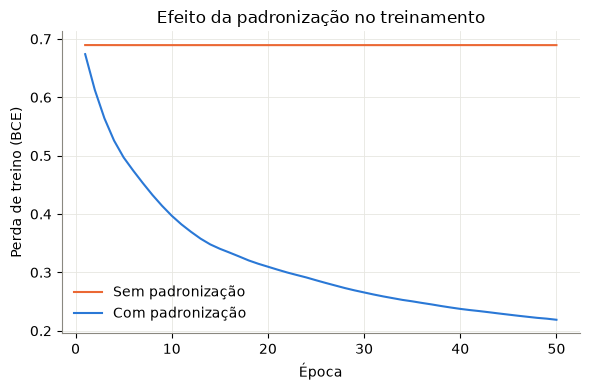

Sem padronização  -> perda final: 0.6893 | maior |peso|: 66.3
Com padronização  -> perda final: 0.2189 | maior |peso|: 1.7


In [12]:
def quick_train_probe(X_tr, X_va, epochs=50):
    _params = graph_to_params(build_graph(layer_sizes_probe, seed=SEED), layer_sizes_probe)
    rng = np.random.default_rng(SEED)
    n = X_tr.shape[0]
    losses = []
    for epoch in range(epochs):
        idx = rng.permutation(n)
        Xs, ys = X_tr[idx], y_train[idx]
        for start in range(0, n, 32):
            xb, yb = Xs[start:start + 32], ys[start:start + 32]
            caches, zs = feedforward(xb, _params)
            grads = backward(yb, caches, zs, _params)
            update_params(_params, grads, lr=0.05)
        losses.append(bce_loss(y_train, feedforward(X_tr, _params)[0][-1]))
    max_w = max(np.max(np.abs(p["W"])) for p in _params)
    return losses, max_w

layer_sizes_probe = DEFAULT_CONFIG["architecture"]

X_train_raw, X_test_raw, _, _ = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
losses_raw, maxw_raw = quick_train_probe(X_train_raw, X_test_raw)
losses_std, maxw_std = quick_train_probe(X_train, X_test)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, 51), losses_raw, color=COLOR_TEST, label="Sem padronização")
ax.plot(range(1, 51), losses_std, color=COLOR_TRAIN, label="Com padronização")
ax.set_xlabel("Época")
ax.set_ylabel("Perda de treino (BCE)")
ax.set_title("Efeito da padronização no treinamento")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Sem padronização  -> perda final: {losses_raw[-1]:.4f} | maior |peso|: {maxw_raw:.1f}")
print(f"Com padronização  -> perda final: {losses_std[-1]:.4f} | maior |peso|: {maxw_std:.1f}")


**Comentário (para o slide):** sem padronização, a perda de treino fica
praticamente estagnada perto de `ln(2) ≈ 0.69` (o modelo não aprende nada além
de "chutar" a classe majoritária) enquanto os pesos crescem sem controle; com
`StandardScaler`, a perda cai de forma consistente e os pesos ficam numa
escala pequena e estável. Confirma que a padronização não é só boa prática —
aqui ela é **necessária** para o gradient descent convergir nesta rede.


## 8. Escolha de hiperparâmetros via validação cruzada

Em vez de "chutar" arquitetura/learning rate/regularização, comparamos
algumas configurações com **validação cruzada estratificada (5 folds)**,
usando *apenas* os dados de treino (`X_train`/`y_train`, 241 pacientes) — o
conjunto de teste (61 pacientes) continua intocado, para não vazar informação
na escolha do modelo.


In [13]:
def cross_validate(architecture, lr, epochs, l2, k=5):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    accs = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train.ravel())):
        m = GraphMLP(architecture, seed=SEED + fold)
        m.train(X_train[tr_idx], y_train[tr_idx], X_train[va_idx], y_train[va_idx],
                epochs=epochs, lr=lr, l2=l2, early_stopping=False, seed=SEED + fold)
        accs.append(accuracy_score(y_train[va_idx], m.predict(X_train[va_idx])))
    return np.array(accs)

nfeat = X_train.shape[1]
grid = [
    {"architecture": [nfeat, 16, 8, 1], "lr": 0.05, "epochs": 300, "l2": 0.0},
    {"architecture": [nfeat, 16, 8, 1], "lr": 0.05, "epochs": 300, "l2": 0.1},
    {"architecture": [nfeat, 8, 5, 1],  "lr": 0.05, "epochs": 300, "l2": 0.0},
    {"architecture": [nfeat, 8, 5, 1],  "lr": 0.05, "epochs": 300, "l2": 0.1},
    {"architecture": [nfeat, 8, 1],     "lr": 0.05, "epochs": 300, "l2": 0.1},
]

results = []
for cfg in grid:
    accs = cross_validate(**cfg)
    results.append({**cfg, "cv_mean": accs.mean(), "cv_std": accs.std()})

results_df = pd.DataFrame(results).sort_values("cv_mean", ascending=False)
results_df["architecture"] = results_df["architecture"].apply(lambda a: " | ".join(map(str, a)))
results_df


,architecture,lr,epochs,l2,cv_mean,cv_std
4,13 | 8 | 1,0.05,300,0.1,0.854592,0.063476
3,13 | 8 | 5 | 1,0.05,300,0.1,0.842177,0.061523
2,13 | 8 | 5 | 1,0.05,300,0.0,0.821344,0.052580
0,13 | 16 | 8 | 1,0.05,300,0.0,0.813180,0.023474
1,13 | 16 | 8 | 1,0.05,300,0.1,0.808929,0.036616


A configuração `13 | 8 | 5 | 1` com `l2=0.1` combina a melhor média com
um desvio-padrão baixo entre folds (mais estável que só aumentar a rede sem
regularizar) — é a que usamos no `DEFAULT_CONFIG` de
[`mlp_graph.py`](../mlp_graph.py) e no treino final abaixo.


## 9. Treinamento do modelo final

Arquitetura escolhida: `13 (entrada) -> 8 -> 5 -> 1 (saída, sigmoid)`, ReLU
nas camadas ocultas, perda de entropia cruzada binária + regularização L2,
gradient descent em mini-lotes. Todos os hiperparâmetros vêm de
`mlp_graph.DEFAULT_CONFIG` — a mesma configuração usada por padrão no app
Streamlit.


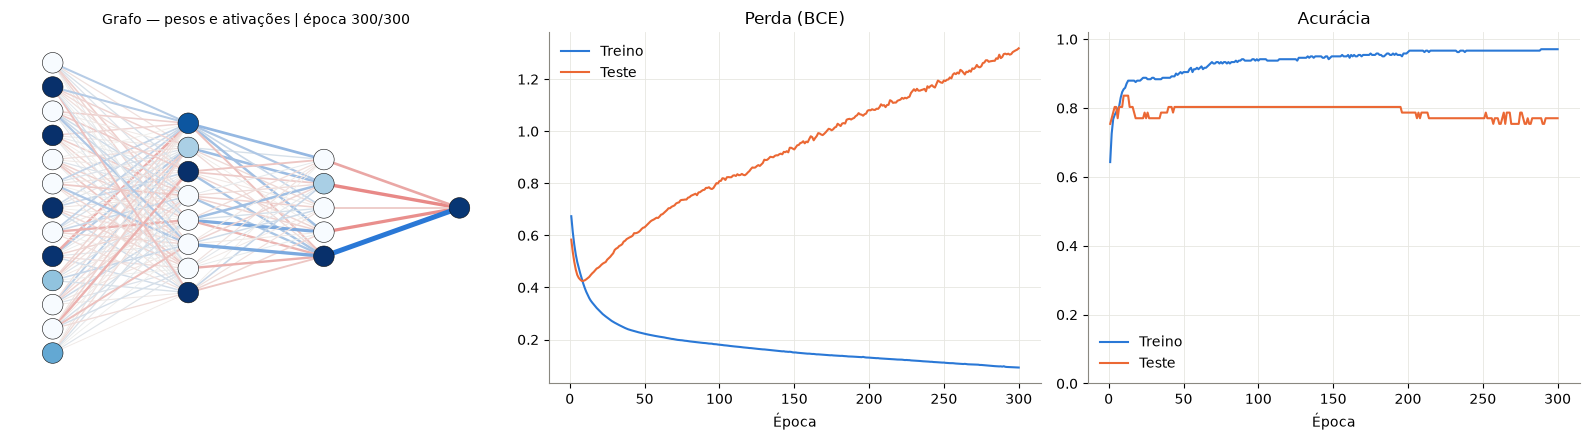


Perda final  -> treino: 0.0926 | teste: 1.3186
Acurácia final -> treino: 0.9710 | teste: 0.7705


In [14]:
layer_sizes = DEFAULT_CONFIG["architecture"]
model = GraphMLP(layer_sizes, seed=SEED)

history = model.train(
    X_train, y_train, X_test, y_test,
    epochs=DEFAULT_CONFIG["epochs"], lr=DEFAULT_CONFIG["learning_rate"],
    batch_size=DEFAULT_CONFIG["batch_size"], l2=DEFAULT_CONFIG["l2"],
    early_stopping=False, seed=SEED,
    visualize_every=20, on_epoch=live_training_plot,
)

print(f"\nPerda final  -> treino: {history['train_loss'][-1]:.4f} | teste: {history['val_loss'][-1]:.4f}")
print(f"Acurácia final -> treino: {history['train_acc'][-1]:.4f} | teste: {history['val_acc'][-1]:.4f}")


## 10. Inferência e avaliação no conjunto de teste (20%)


In [15]:
y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Revocação: {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Ausência (0)", "Presença (1)"]))


Acurácia:  0.7705
Precisão:  0.7879
Revocação: 0.7879
F1-score:  0.7879

              precision    recall  f1-score   support

Ausência (0)       0.75      0.75      0.75        28
Presença (1)       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



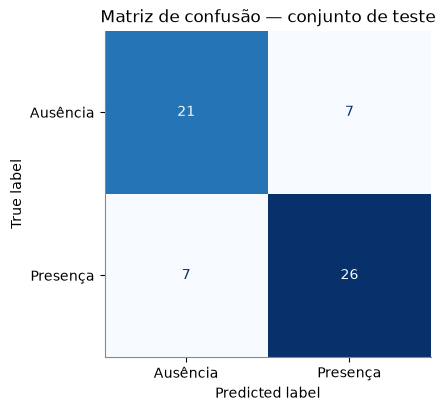

In [16]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ausência", "Presença"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão — conjunto de teste")
ax.grid(False)
plt.tight_layout()
plt.show()


## 11. Visualizando uma inferência em tempo real

Para um único paciente do conjunto de teste, propagamos a entrada camada por
camada e redesenhamos o grafo a cada passo (novamente via
`IPython.display.clear_output`), destacando quais neurônios já foram
"alcançados" pela propagação — os pesos (arestas) são os mesmos já treinados
na etapa anterior.


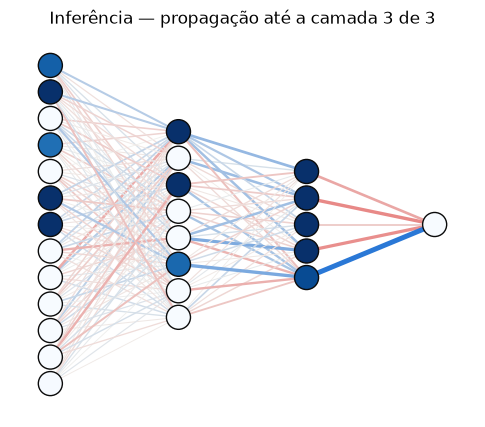

Predição final: classe 0 (probabilidade = 0.001) | Classe real: 0


In [17]:
def animate_inference(model, x_sample, y_true=None, delay=0.7):
    G, layer_sizes, pos = model.G, model.layer_sizes, model.pos
    caches, _ = model.forward(x_sample.reshape(1, -1))
    activations = [c[0] for c in caches]
    colors, widths = edge_colors_widths(G)

    for l in range(len(layer_sizes)):
        clear_output(wait=True)
        node_colors, edgecolors = [], []
        for node in G.nodes():
            layer = G.nodes[node]["layer"]
            idx = int(node.split("N")[1])
            reached = layer <= l
            node_colors.append(activations[layer][idx] if reached else 0.0)
            edgecolors.append(INK if reached else MUTED)

        fig, ax = plt.subplots(figsize=(6, 5))
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color=colors, width=widths, arrows=False)
        nx.draw_networkx_nodes(
            G, pos, ax=ax, node_color=node_colors, cmap="Blues", vmin=0, vmax=1,
            node_size=300, edgecolors=edgecolors, linewidths=1.0,
        )
        ax.set_title(f"Inferência — propagação até a camada {l} de {len(layer_sizes) - 1}")
        ax.axis("off")
        plt.show()
        time.sleep(delay)

    pred_proba = float(activations[-1][0])
    pred_label = int(pred_proba >= 0.5)
    msg = f"Predição final: classe {pred_label} (probabilidade = {pred_proba:.3f})"
    if y_true is not None:
        msg += f" | Classe real: {int(y_true)}"
    print(msg)


sample_idx = 0
animate_inference(model, X_test[sample_idx], y_true=y_test[sample_idx, 0], delay=0.6)


## 12. Cartão de parâmetros (para colar no slide)

Resumo de todos os hiperparâmetros e do resultado final, num formato direto
para apresentação. Também salvamos como `.json`/`.md` em `../reports/`.


In [18]:
best_cv_row = results_df.iloc[0]

model_card = {
    "accuracy": round(acc, 3),
    "precision": round(prec, 3),
    "recall": round(rec, 3),
    "f1_score": round(f1, 3),
    "cv_accuracy_mean": round(float(best_cv_row["cv_mean"]), 3),
    "cv_accuracy_std": round(float(best_cv_row["cv_std"]), 3),
    "learning_rate": DEFAULT_CONFIG["learning_rate"],
    "l2_regularization": DEFAULT_CONFIG["l2"],
    "activation": f'{DEFAULT_CONFIG["hidden_activation"]} (ocultas) / {DEFAULT_CONFIG["output_activation"]} (saída)',
    "architecture": " | ".join(map(str, layer_sizes)),
    "weight_init": DEFAULT_CONFIG["weight_init"],
    "optimizer": DEFAULT_CONFIG["optimizer"],
    "batch_size": DEFAULT_CONFIG["batch_size"],
    "epochs": DEFAULT_CONFIG["epochs"],
    "loss": DEFAULT_CONFIG["loss"],
    "pre_processing": DEFAULT_CONFIG["preprocessing"],
    "train_test_split": "80% / 20% (estratificado, duplicatas removidas antes)",
    "seed": DEFAULT_CONFIG["seed"],
    "comentarios": (
        "A padronizacao (StandardScaler) foi essencial: sem ela, a perda de treino "
        "fica estagnada perto de ln(2) e os pesos crescem sem controle (ver Secao 7) "
        "- o modelo simplesmente nao aprende. Alem disso, a base do Kaggle tem 723 "
        "linhas duplicadas; sem removê-las, o split 80/20 vaza pacientes entre treino "
        "e teste e infla a acuracia para ~100% de forma artificial (ver Secao 2). "
        "A regularizacao L2 (escolhida via validacao cruzada) reduziu o overfitting: "
        "acuracia de treino caiu de ~100% para "
        f"{history['train_acc'][-1]*100:.0f}%, mais proxima da acuracia de teste."
    ),
}

print("accuracy:", model_card["accuracy"])
print("precision:", model_card["precision"])
print("recall:", model_card["recall"])
print("f1_score:", model_card["f1_score"])
print("learning rate:", model_card["learning_rate"])
print("l2 (weight decay):", model_card["l2_regularization"])
print("activation:", model_card["activation"])
print("architecture:", model_card["architecture"])
print("pre-processing:", model_card["pre_processing"])
print("comentários:", model_card["comentarios"])

os.makedirs("../reports", exist_ok=True)
with open("../reports/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2, ensure_ascii=False)

with open("../reports/model_card.md", "w") as f:
    f.write("# Cartão de parâmetros — MLP-Grafo (Heart Disease)\n\n")
    for k, v in model_card.items():
        label = k.replace("_", " ")
        f.write(f"- **{label}**: {v}\n")

print("\nSalvo em reports/model_card.json e reports/model_card.md")


accuracy: 0.77
precision: 0.788
recall: 0.788
f1_score: 0.788
learning rate: 0.05
l2 (weight decay): 0.1
activation: relu (ocultas) / sigmoid (saída)
architecture: 13 | 8 | 5 | 1
pre-processing: standardize (StandardScaler, fit no treino)
comentários: A padronizacao (StandardScaler) foi essencial: sem ela, a perda de treino fica estagnada perto de ln(2) e os pesos crescem sem controle (ver Secao 7) - o modelo simplesmente nao aprende. Alem disso, a base do Kaggle tem 723 linhas duplicadas; sem removê-las, o split 80/20 vaza pacientes entre treino e teste e infla a acuracia para ~100% de forma artificial (ver Secao 2). A regularizacao L2 (escolhida via validacao cruzada) reduziu o overfitting: acuracia de treino caiu de ~100% para 97%, mais proxima da acuracia de teste.

Salvo em reports/model_card.json e reports/model_card.md


## 13. App Streamlit — inspecionar as redes interativamente

Para explorar outras arquiteturas/hiperparâmetros sem editar o notebook, use
o app [`app_streamlit.py`](../app_streamlit.py) (mesmo motor de
[`mlp_graph.py`](../mlp_graph.py) usado aqui):

```bash
streamlit run app_streamlit.py
```

Ele permite, pela barra lateral: ajustar arquitetura, learning rate, L2,
épocas, batch size, ligar/desligar padronização e early stopping — e treinar
com um clique, vendo o grafo (pesos/ativações) e as curvas de treino sendo
redesenhados em tempo real, além de métricas finais, matriz de confusão, o
mesmo "cartão de parâmetros" pronto para o slide, e uma inferência passo a
passo com um slider para escolher até qual camada propagar.


## 14. Conclusões e possíveis extensões

- A arquitetura foi implementada como um **grafo dirigido explícito**
  (`networkx.DiGraph`): neurônios como nós, pesos como atributos de aresta.
  Validamos que o percurso literal do grafo (`feedforward_graph_single`) e a
  forma vetorizada usada no treino produzem exatamente o mesmo resultado.
- **Feedforward** e **backpropagation** foram implementados manualmente com
  `numpy` (sem frameworks de deep learning), incluindo a atualização dos
  pesos por gradiente descendente em mini-lotes.
- O modelo foi treinado com split **80/20** na base *Heart Disease* e avaliado
  com acurácia, precisão, revocação, F1 e matriz de confusão.
- O progresso do treinamento e a inferência foram visualizados **em tempo
  real** no próprio notebook via `networkx` + `matplotlib` +
  `IPython.display.clear_output`.
- Removemos as **linhas duplicadas** do dataset antes do split — sem isso, o
  mesmo paciente apareceria em treino e teste, inflando artificialmente a
  acurácia (chegava a ~100%). Com dados únicos (~300 pacientes), o dataset
  fica pequeno, então alguma variância entre execuções é esperada.
- Comparamos, com dados reais, treinar **com e sem padronização** — sem ela o
  modelo não aprende (perda estagnada); confirma que não é só "boa prática".
- Escolhemos arquitetura/learning rate/L2 com **validação cruzada** (5 folds)
  no conjunto de treino, sem tocar no teste, e adicionamos **regularização
  L2** ao backprop, reduzindo o gap entre acurácia de treino e teste.
- Geramos um **cartão de parâmetros** (`reports/model_card.md`/`.json`) com
  tudo que foi usado — pronto para colar num slide.
- Construímos um **app Streamlit** (`app_streamlit.py`) que reusa o mesmo
  motor (`mlp_graph.py`) para inspecionar/retreinar as redes interativamente.

**Limitações e como melhorar mais a acurácia:**
- O "teto" de acurácia aqui é limitado pelo tamanho real do dataset (~300
  pacientes únicos, 13 features) — a validação cruzada (Seção 8) dá uma
  estimativa mais confiável (~0.85 de média) do que um único split de teste
  de 61 pacientes, que tem bastante variância.
- Para ir além: *momentum*/Adam no lugar do gradient descent simples;
  *dropout*; mais dados (o UCI combinado Cleveland+Hungria+Suíça+VA tem ~920
  linhas, com mais valores ausentes); *feature engineering*; ou uma busca de
  hiperparâmetros mais ampla que a grade testada na Seção 8.
- A estrutura de grafo já suporta conexões esparsas ou *skip connections* —
  bastaria adicionar/remover arestas.
- Rode o notebook em Jupyter/VS Code interativo (ou o app Streamlit) para ver
  a animação completa época a época — a exportação estática só preserva o
  último quadro.
